In [1]:
import torch as tc
import numpy as np
import qutip as qt
import pandas as pd
import function as my
import matplotlib.pyplot as plt
from tqdm import tqdm

class SIN(tc.nn.Module):
    def __init__(self): 
        super(SIN, self).__init__() 
    def forward(self, x):
        return tc.sin(x)

In [2]:
tfinal      = 2.52*np.pi
N           = 100
Nedo        = 3
Nfield      = 1

/home/gubio/anaconda3/lib/python3.13/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


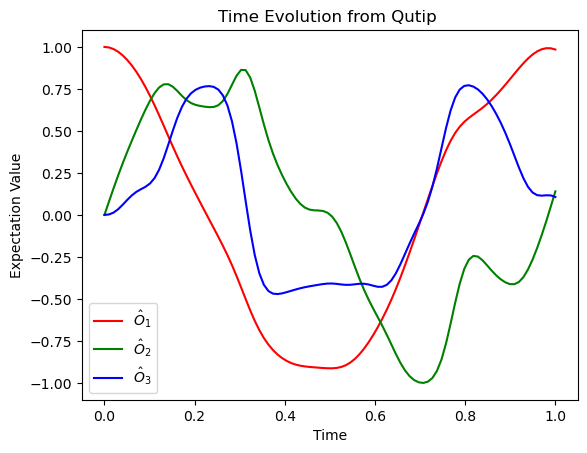

/tmp/ipykernel_6688/1522521491.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


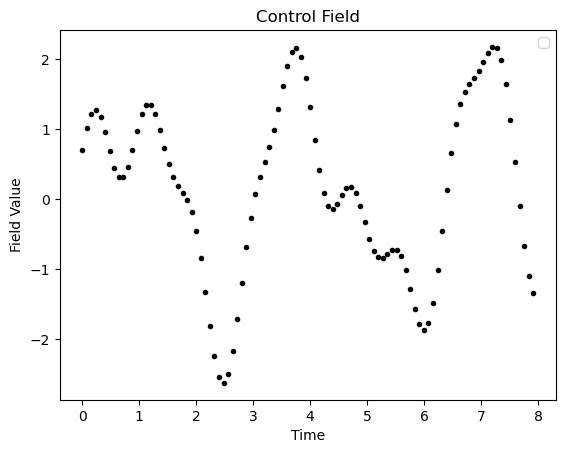

In [3]:
O_op =[ qt.sigmax(),
        qt.sigmay(),
        qt.sigmaz()]

def Field(t):
    return (1.5 * np.sin(2.0 * t) + 0.8 * np.cos(3.5 * t + 0.5) + 0.4 * np.sin(7.0 * t))

def data_qubit(O_op,tlist,field,device="cpu"):
    # Lista de tempos para a evolução
    H0 = 0.5*qt.sigmaz()
    H1 = 0.5*qt.sigmax()
    H  = [H0,[H1,field(tlist)]]
    
    # Hamiltonian Lindbladian
    c_ops = []
    
    # Estado inicial (cada qubit na superposição de |0> e |1>)
    # |+> = (|0> + |1>)/sqrt(2)
    theta1  = np.pi/4
    phi1    = 0.0 #np.pi/3
    ket_plus1 = (np.cos(theta1)*qt.basis(2, 0)+np.sin(theta1)*np.exp(1j*phi1)*qt.basis(2, 1))
    psi0 = ket_plus1
    
    # Solução da equação de Schrödinger
    options = qt.Options(nsteps = 100000, atol = 1e-14, rtol = 1e-14)
    result  = qt.mesolve(H, psi0, tlist, c_ops=c_ops, e_ops=O_op,options=options)

    expect  = tc.tensor( np.array( result.expect),device = device).transpose(0, 1)
    return expect

tlist = np.linspace(0.0, tfinal, N)
valor_esperado_data  = data_qubit(O_op,tlist,Field,device="cpu")

colors = ['r', 'g', 'b']
for i in range(len(O_op)):
    plt.plot(tlist/tfinal,valor_esperado_data[:,i].cpu() ,label=fr"$\hat{{O}}_{{{i+1}}}$", color=colors[i])
    
plt.xlabel('Time')
plt.ylabel('Expectation Value')
plt.legend()
plt.title('Time Evolution from Qutip ')
plt.show()
plt.plot(tlist,Field(tlist),'k.')
plt.xlabel('Time')
plt.ylabel('Field Value')
plt.legend()
plt.title('Control Field')
plt.show()

In [4]:
neuronio = [15,15]
X_vector   = my.Rede(
    neuronio    = neuronio,
    input_      = 1,
    output_     = Nedo+Nfield,
    activation  =[SIN()]*len(neuronio))
opt = tc.optim.Adam(X_vector.parameters(),
        lr = 0.001 )
time =  tc.linspace(
        0,
        tfinal,
        N,
        dtype   = tc.float32,
        requires_grad = True).reshape((-1, 1))

100%|██████████| 50000/50000 [00:48<00:00, 1024.83it/s]


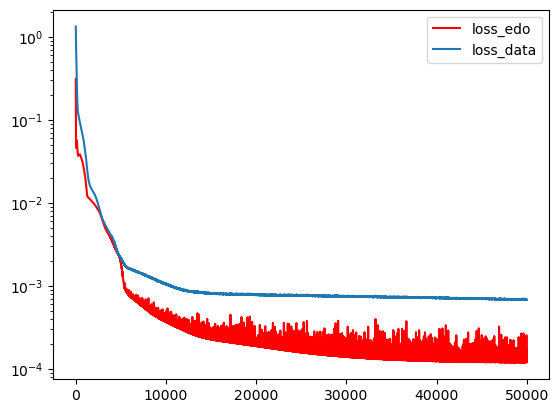

In [5]:
epocas  = 50000
LOSS    = []
LOSS1   = []
LOSS2   = []
hisorty_of_param = []
for _ in tqdm(range(epocas)):
    ####### Forward pass #######
    y  = X_vector(time)

    ######## Loss edo #######
    dX_dt = []
    for i in range(y.shape[1]-1):
        dX_dt.append(tc.autograd.grad(outputs = y[:, i],
                                    inputs = time,
                                    grad_outputs = tc.ones_like(y[:, i]),
                                    #retain_graph = True,
                                    create_graph = True)[0])
    dX_dt   = tc.cat(dX_dt, dim=1)
    JZ = 1e0
    JY = 0e0
    JX = y[:, 3:4] # time-dependent field to be found
    
    X,Y,Z = y[:, 0:1], y[:, 1:2], y[:, 2:3]
    LOSS_edo  = 0
    
    LOSS_edo += (dX_dt[:,0:1] - (-1.0*Y))**2
    LOSS_edo += (dX_dt[:,1:2] - ( 1.0*X - 1.0*JX*Z))**2
    LOSS_edo += (dX_dt[:,2:3] - ( 1.0*JX*Y))**2
    LOSS_edo = LOSS_edo.mean()


    ####### loss data(expected values) #######
    LOSS_data=0    
    LOSS_data +=(y[:,0:1]  - valor_esperado_data[:,0:1])**2 
    LOSS_data +=(y[:,1:2]  - valor_esperado_data[:,1:2])**2 
    LOSS_data +=(y[:,2:3]  - valor_esperado_data[:,2:3])**2 
    LOSS_data = LOSS_data.mean()
    
    ####### Loss total #######
    loss_i = LOSS_edo + LOSS_data

    ####### Backpropagation #######
    opt.zero_grad()
    loss_i.backward()
    opt.step()
    LOSS1.append(LOSS_edo.cpu().detach().numpy())
    LOSS2.append(LOSS_data.cpu().detach().numpy())
    LOSS.append(loss_i.cpu().detach().numpy())

#plt.plot(LOSS,"k.",label="loss_total")
plt.plot(LOSS1,'r-',label="loss_edo")
plt.plot(LOSS2,label="loss_data")
plt.yscale("log")
plt.legend()
plt.show()

# opt = tc.optim.Adam(X_vector.parameters(),
#         lr = 0.001, amsgrad=True)

# epocas  = 10000
# for _ in tqdm(range(epocas)):
#     ####### Forward pass #######
#     y  = X_vector(time)

#     ######## Loss edo #######
#     dX_dt = []
#     for i in range(y.shape[1]-1):
#         dX_dt.append(tc.autograd.grad(outputs = y[:, i],
#                                     inputs = time,
#                                     grad_outputs = tc.ones_like(y[:, i]),
#                                     #retain_graph = True,
#                                     create_graph = True)[0])
#     dX_dt   = tc.cat(dX_dt, dim=1)
#     JZ = 1e0
#     JY = 0e0
#     JX = y[:, 3:4] # time-dependent field to be found
    
#     X,Y,Z = y[:, 0:1], y[:, 1:2], y[:, 2:3]
#     LOSS_edo  = 0
    
#     LOSS_edo += (dX_dt[:,0:1] - (-1.0*Y))**2
#     LOSS_edo += (dX_dt[:,1:2] - ( 1.0*X - 1.0*JX*Z))**2
#     LOSS_edo += (dX_dt[:,2:3] - ( 1.0*JX*Y))**2
#     LOSS_edo = LOSS_edo.mean()

#     ####### loss data(expected values) #######
#     LOSS_data=0    
#     LOSS_data +=(y[:,0:1]  - valor_esperado_data[:,0:1])**2 
#     LOSS_data +=(y[:,1:2]  - valor_esperado_data[:,1:2])**2 
#     LOSS_data +=(y[:,2:3]  - valor_esperado_data[:,2:3])**2 
#     LOSS_data = LOSS_data.mean()
    
#     ####### Loss total #######
#     loss_i = LOSS_edo + LOSS_data

#     ####### Backpropagation #######
#     opt.zero_grad()
#     loss_i.backward()
#     opt.step()
#     LOSS1.append(LOSS_edo.cpu().detach().numpy())
#     LOSS2.append(LOSS_data.cpu().detach().numpy())
#     LOSS.append(loss_i.cpu().detach().numpy())

# #plt.plot(LOSS,"k.",label="loss_total")
# plt.plot(LOSS1,'r-',label="loss_edo")
# plt.plot(LOSS2,label="loss_data")
# plt.yscale("log")
# plt.legend()
# plt.show()



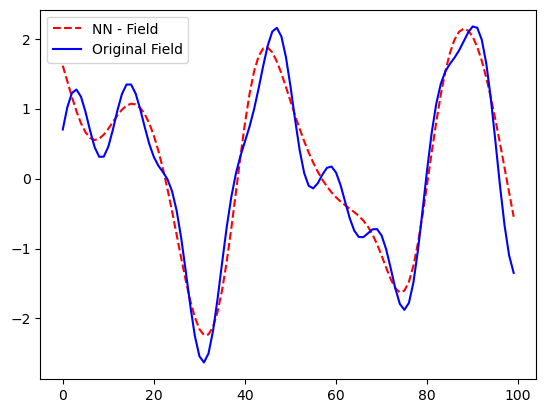

In [6]:
t_points =  np.linspace(0,tfinal, N)
X_vector.eval()
X_  = X_vector(time).detach().numpy()

field_original=Field(t_points)
plt.plot(X_[:,3],"r--",label="NN - Field")
plt.plot(field_original,"b-",label="Original Field")
plt.legend()
plt.show()

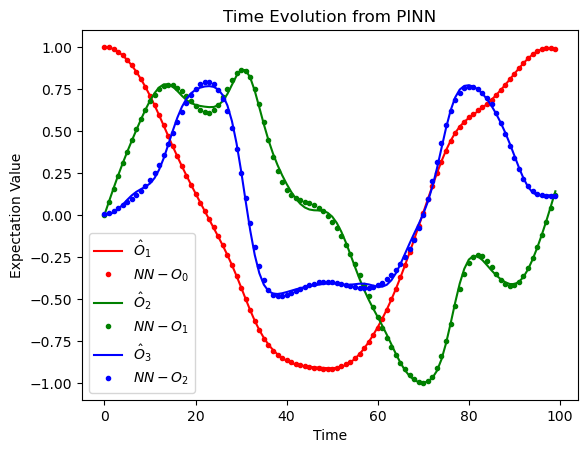

In [7]:
t_points =  np.linspace(0,tfinal, N)
X_vector.eval()
X_  = X_vector(time).detach().numpy()

colors = ['r', 'g', 'b']
for i in range(len(O_op)):
    plt.plot(valor_esperado_data[:,i].cpu() ,label=fr"$\hat{{O}}_{{{i+1}}}$", color=colors[i])
    plt.plot(X_[:,i],"." ,label=fr"$NN - O_{{{i}}}$", color=colors[i])
plt.xlabel('Time')
plt.ylabel('Expectation Value')
plt.legend()
plt.title('Time Evolution from PINN')
plt.show()


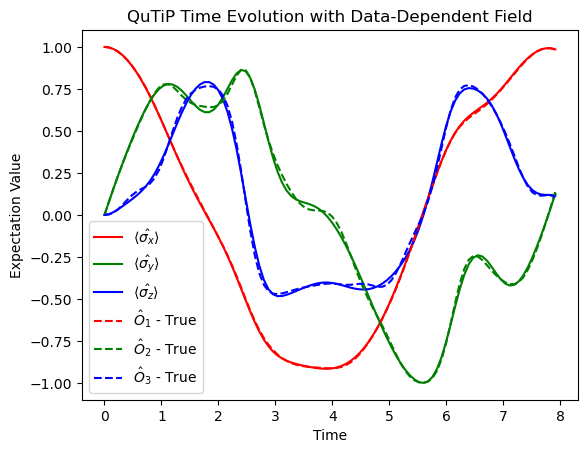

In [9]:
H0 = .5*qt.sigmaz()
H1 = .5*qt.sigmax()
# The full Hamiltonian is defined as a list: 
# H = H0 + f(t) * H1, where f(t) is the field data
H = [H0, [H1, X_[:,3]]] # QuTiP uses cubic spline interpolation for field_data

# (Optional) Define collapse operators for an open system simulation
c_ops = [] # e.g., c_ops = [np.sqrt(gamma) * qt.sigmam()]

# 3. Define the initial state and expectation value operators
theta1  = np.pi/4
phi1    = 0.0 #np.pi/3
psi0    = (np.cos(theta1)*qt.basis(2, 0)+np.sin(theta1)*np.exp(1j*phi1)*qt.basis(2, 1))

O_op =[ qt.sigmax(),
         qt.sigmay(),
         qt.sigmaz()
                ]

# 4. Simulate the time evolution
options = qt.Options(nsteps = 100000, atol = 1e-14, rtol = 1e-14)
result  = qt.mesolve(H, psi0, t_points, c_ops=c_ops, e_ops=O_op,options=options)

# 5. Plot the results
plt.figure()
plt.plot(t_points, result.expect[0],"r-", label=r'$\langle \hat{\sigma_x}\rangle$',)
plt.plot(t_points, result.expect[1],"g-", label=r'$\langle \hat{\sigma_y}\rangle$')
plt.plot(t_points, result.expect[2],"b-", label=r'$\langle \hat{\sigma_z}\rangle$')

plt.plot(t_points,valor_esperado_data[:,0].cpu() ,label=fr"$\hat{{O}}_{{1}}$ - True", color='r', linestyle='--')
plt.plot(t_points,valor_esperado_data[:,1].cpu() ,label=fr"$\hat{{O}}_{{2}}$ - True", color='g', linestyle='--')
plt.plot(t_points,valor_esperado_data[:,2].cpu() ,label=fr"$\hat{{O}}_{{3}}$ - True", color='b', linestyle='--')


plt.xlabel('Time')
plt.ylabel('Expectation Value')
plt.legend()
plt.title('QuTiP Time Evolution with Data-Dependent Field')
plt.show()